# **데이터 불러오기**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
import re
from scipy.stats import chi2_contingency, binomtest, fisher_exact, chisquare
from collections import Counter
from itertools import product

pd.set_option('display.max_columns', None)

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'

In [2]:
# ============================================================
# 한글 폰트 설치 및 적용
# ============================================================

!apt-get -qq install -y fonts-nanum > /dev/null
!pip -q install scipy pandas matplotlib

import matplotlib.font_manager as fm
for f in fm.findSystemFonts():
    if 'Nanum' in f:
        fm.fontManager.addfont(f)
print("폰트 설치 완료 → 런타임을 한 번 다시 시작하세요.")


plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

폰트 설치 완료 → 런타임을 한 번 다시 시작하세요.


In [3]:
#파일 불러오기
df = pd.read_csv('FDA_adverse_events_final_참조표병합.csv')
df.shape

(18273, 37)

In [4]:
df['WHO_ATC'].value_counts(dropna=False)

,count
WHO_ATC,
A,9622
N,4324
M,1975
R,1562
D,641
B,94
S,55


# **S(감각기관용제, 안과용) : 총 55건**   
# **항알레르기 점안제 : 30건**

항알레르기 점안제 vs 인공눈물

*   **항알레르기 점안제 - 올라파타딘** : 16

*   **항알레르기 점안제 - 케토티펜** : 14

*   **인공눈물** : 25



In [5]:
# ============================================================
# [셀 0] 공통 설정 (반드시 먼저 한 번 실행)
# ============================================================

# ----- 색상 팔레트 -----
C_ANTI   = '#2563eb'   # 항알레르기 점안제 (파랑, 주 강조색)
C_SGROUP = '#0891b2'   # S그룹 (하늘색)
C_BASE   = '#94a3b8'   # baseline (회색 전용)
C_FEMALE = '#db2777'   # 여성 (핑크)
C_MALE   = '#0891b2'   # 남성 (하늘색)
C_RED    = '#dc2626'   # 부정(serious=Yes / 미회복)
C_GREEN  = '#16a34a'   # 긍정(serious=No / 회복)

# ----- 서브셋 정의 -----
atc = df['도출_ATC코드'].astype(str).str.strip().str.upper()
first = atc.str[0]

ANTI_CODES = ['S01GX08', 'S01GX09']          # 케토티펜 + 올로파타딘
anti = df[atc.isin(ANTI_CODES)].copy()        # 항알레르기 점안제
s_df = df[first == 'S'].copy()                # S그룹 전체

N_ANTI = len(anti)
N_S    = len(s_df)
N_ALL  = len(df)
print(f"항알레르기 점안제 n={N_ANTI} / S그룹 n={N_S} / 전체 n={N_ALL}")

# ----- 성분 이름 매핑 -----
NAME_MAP = {'S01GX08':'케토티펜','S01GX09':'올로파타딘',
            'S01XA08':'인공눈물(XA08)','S01XA20':'인공눈물(XA20)'}

# ----- 연령대 한글 매핑 -----
AGE_KR = {
    'Infant(0-2)':'영아(0-2)', 'Child(3-12)':'소아(3-12)', 'Teen(13-18)':'청소년(13-18)',
    'Adult(19-40)':'성인(19-40)', 'Middle-Aged(41-65)':'중년(41-65)',
    'Senior(66-80)':'고령(66-80)', 'Elderly(81+)':'초고령(81+)',
}

# ----- 부작용명 한글 매핑 (없으면 원문 유지) -----
REACTION_KR = {
    'Drug ineffective':'약효 없음', 'Eye irritation':'눈 자극감', 'Eye pain':'눈 통증',
    'Treatment failure':'치료 실패', 'Overdose':'과다 투여', 'Ocular hyperaemia':'결막 충혈',
    'Eye pruritus':'눈 가려움', 'Off label use':'허가외 사용',
    'Drug effect incomplete':'약효 불충분', 'Eyelid margin crusting':'눈꺼풀 딱지',
    'Eye swelling':'눈 부종', 'Application site discomfort':'점안 부위 불편감',
    'Application site pain':'점안 부위 통증', 'Drug abuse':'약물 오남용',
    'Intentional self-injury':'고의적 자해', 'Vomiting':'구토',
    'Condition aggravated':'증상 악화', 'Pruritus':'가려움', 'Dyspnoea':'호흡곤란',
    'Eye haemorrhage':'눈 출혈', 'Headache':'두통', 'Mixed liver injury':'혼합형 간손상',
    'Incorrect dose administered by device':'기기 용량 오투여', 'Device issue':'기기 결함',
    'Conjunctivitis allergic':'알레르기성 결막염', 'Sinusitis':'부비동염', 'Malaise':'권태감',
    'Back pain':'요통', 'Product container issue':'용기 문제',
    'Drug dispensing error':'조제 오류', 'Vision blurred':'시야 흐림',
    'Incorrect dose administered':'용량 오투여',
    'Decreased immune responsiveness':'면역반응 저하', 'Lung infection':'폐 감염',
    'Foreign body sensation in eyes':'눈 이물감', 'Eye infection':'눈 감염',
    'Gastrointestinal inflammation':'위장관 염증', 'Abdominal pain':'복통',
    'Aphonia':'발성 불능', 'Asthma':'천식', 'Inflammation':'염증',
    'Skin irritation':'피부 자극', 'Drug ineffective for unapproved indication':'허가외 적응증 약효 없음',
    'Accidental overdose':'우발적 과다투여', 'Product use issue':'제품 사용 문제',
    'Product dose omission issue':'투여 누락', 'Product use in unapproved indication':'허가외 적응증 사용',
    'Product prescribing error':'처방 오류', 'Wrong technique in product usage process':'잘못된 사용법',
}
def rk(name):
    """부작용명 한글 변환 (매핑 없으면 원문)"""
    return REACTION_KR.get(name, name)

SMALL_WARN = ("※ 항알레르기 점안제 n=30 소표본. 아래 수치·검정은 모두 '신고 경향'이며 발생률·인과 아님.\n"
              "  통계검정은 기대빈도가 낮아 방향성 참고용으로만 해석하세요.")
print(SMALL_WARN)


def choose_and_run_test(contingency, label=""):
    """2xk 분할표에 상황에 맞는 검정 자동 선택.
       2x2 & 기대빈도<5 → Fisher's exact / 그 외 → chi-square(+Cramér's V)."""
    obs = np.asarray(contingency, dtype=float)
    chi2, p_chi, dof, exp = chi2_contingency(obs)
    low = int((exp < 5).sum())
    is_2x2 = obs.shape == (2, 2)
    print(f"\n[통계검정] {label}")
    print(f"  분할표 {obs.shape}, 기대빈도<5 셀 {low}/{obs.size}")
    if is_2x2 and low > 0:
        odds, p = fisher_exact(obs)
        print(f"  → Fisher's exact (2x2 & 기대빈도 부족)")
        print(f"  odds ratio={odds:.3f}, p-value={p:.4f}")
    else:
        p = p_chi
        n = obs.sum(); k = min(obs.shape) - 1
        v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
        tag = " (⚠기대빈도<5 존재, 참고용)" if low else ""
        print(f"  → Chi-square{tag}")
        print(f"  chi2={chi2:.3f}, dof={dof}, p-value={p:.4f}, Cramér's V={v:.3f}")
    print("  " + ("유의미(p<0.05)" if p < 0.05 else "유의미하지 않음(p≥0.05)")
          + " — 소표본이므로 방향성만 참고")
    return p


def or_ci_2x2(a, b, c, d):
    """2x2 오즈비와 95% CI (Haldane 보정)."""
    a_, b_, c_, d_ = a + .5, b + .5, c + .5, d + .5
    orv = (a_ * d_) / (b_ * c_)
    se = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
    return orv, np.exp(np.log(orv)-1.96*se), np.exp(np.log(orv)+1.96*se)




항알레르기 점안제 n=30 / S그룹 n=55 / 전체 n=18273
※ 항알레르기 점안제 n=30 소표본. 아래 수치·검정은 모두 '신고 경향'이며 발생률·인과 아님.
  통계검정은 기대빈도가 낮아 방향성 참고용으로만 해석하세요.


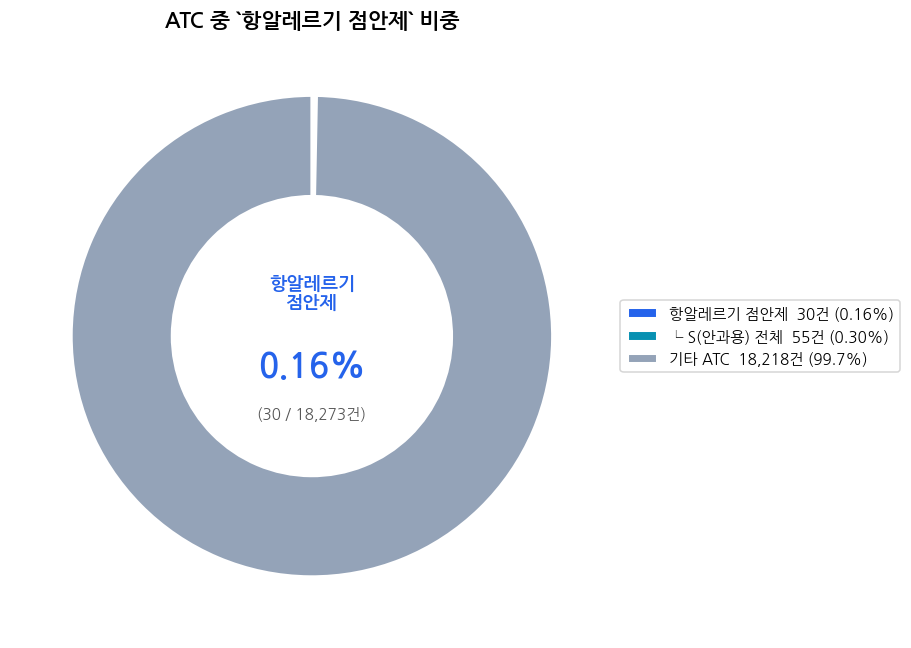


[인사이트]
- 항알레르기 점안제는 전체 18,273건 중 30건으로 0.16% (희소 신고).
- S그룹(55건) 안에서는 항알레르기 점안제가 30건으로 절반 이상(54.5%) 차지.
  → S그룹의 대표 성격이 '알레르기성 결막염 치료'임을 보여줌.


In [6]:
# ============================================================
# [셀 1] 전체 ATC 중 항알레르기 점안제 비중 (도넛)
# ============================================================

n_anti   = N_ANTI
n_s_rest = N_S - N_ANTI          # S그룹 중 항알레르기 제외(=인공눈물)
n_other  = N_ALL - N_S           # S그룹 외 전체

sizes  = [n_anti, n_s_rest, n_other]
# 조각(파랑=항알레르기 / 하늘=인공눈물 / 회색=기타)은 그대로 두되,
# 범례는 'S그룹 전체(55건)' 기준으로 표기해 혼란 제거
labels = [f'항알레르기 점안제  {n_anti}건 ({n_anti/N_ALL*100:.2f}%)',
          f'└ S(안과용) 전체  {N_S}건 ({N_S/N_ALL*100:.2f}%)',
          f'기타 ATC  {n_other:,}건 ({n_other/N_ALL*100:.1f}%)']
colors = [C_ANTI, C_SGROUP, C_BASE]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts = ax.pie(
    sizes, colors=colors, startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2)
)
ax.set_title('ATC 중 `항알레르기 점안제` 비중', fontweight='bold', fontsize=14)
ax.text(0, 0.12, '항알레르기\n점안제', ha='center', fontsize=12, fontweight='bold', color=C_ANTI)
ax.text(0, -0.16, f'{n_anti/N_ALL*100:.2f}%', ha='center', fontsize=22, fontweight='bold', color=C_ANTI)
ax.text(0, -0.34, f'({n_anti} / {N_ALL:,}건)', ha='center', fontsize=10, color='#555')
ax.legend(wedges, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10)
plt.tight_layout(); plt.show()

print(f"""
[인사이트]
- 항알레르기 점안제는 전체 {N_ALL:,}건 중 {n_anti}건으로 {n_anti/N_ALL*100:.2f}% (희소 신고).
- S그룹({N_S}건) 안에서는 항알레르기 점안제가 {n_anti}건으로 절반 이상({n_anti/N_S*100:.1f}%) 차지.
  → S그룹의 대표 성격이 '알레르기성 결막염 치료'임을 보여줌.""")

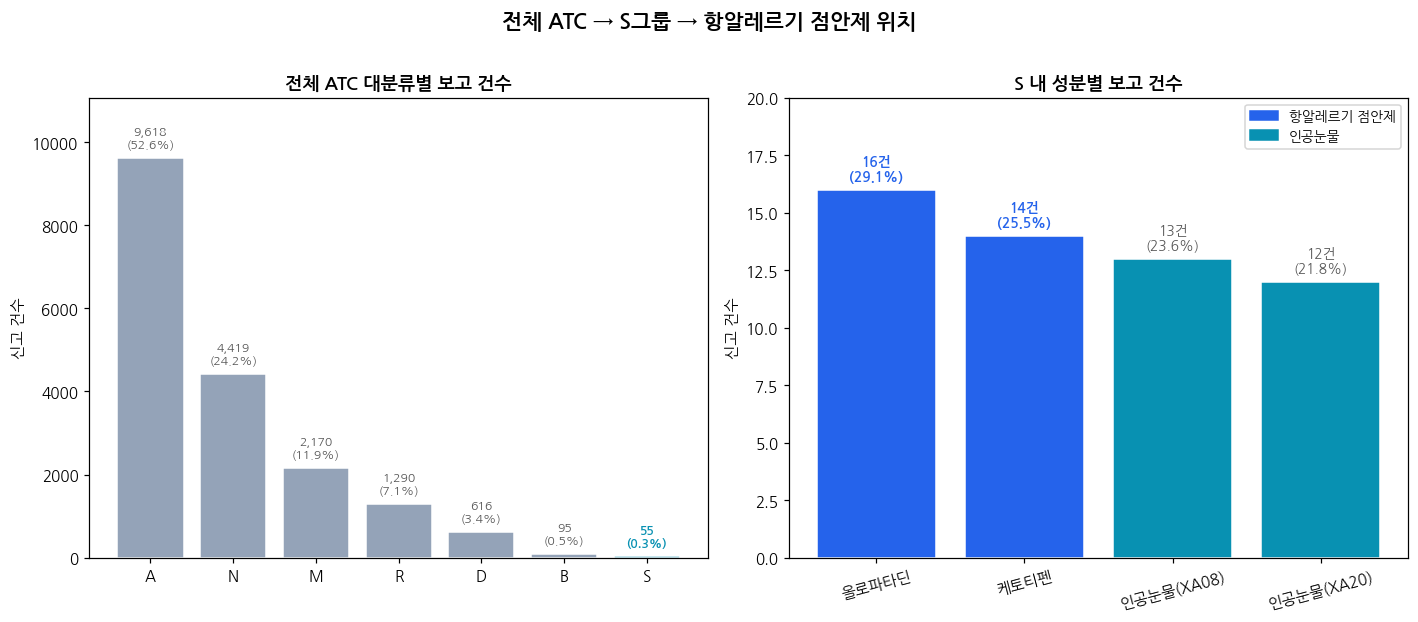


[인사이트]
- ATC 대분류 중 S그룹은 0.30%로 최하위권.
- S그룹 내부는 항알레르기 점안제(케토티펜+올로파타딘 30건)와 인공눈물(25건)이
  양분 → 항알레르기 계열이 54.5%로 근소 우위.


In [7]:
# ============================================================
# [셀 2] 전체 ATC→S그룹→항알레르기 점안제 위치
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# 좌: ATC 대분류별 건수 (S 강조)
grp = first.value_counts()
grp = grp[grp.index != '-'].sort_values(ascending=False)
codes1, vals1 = list(grp.index), grp.values
colors1 = [C_SGROUP if c == 'S' else C_BASE for c in codes1]
bars1 = ax1.bar(codes1, vals1, color=colors1, edgecolor='white')
for b, c, v in zip(bars1, codes1, vals1):
    ax1.text(b.get_x()+b.get_width()/2, v + N_ALL*0.01,
             f'{v:,}\n({v/N_ALL*100:.1f}%)', ha='center', va='bottom',
             fontsize=8, fontweight='bold' if c == 'S' else 'normal',
             color=C_SGROUP if c == 'S' else '#555')
ax1.set_ylabel('신고 건수'); ax1.set_ylim(0, max(vals1)*1.15)
ax1.set_title('전체 ATC 대분류별 보고 건수', fontweight='bold')

# 우: S그룹 내부 - 항알레르기(2성분) vs 인공눈물(2성분), 항알레르기 강조
s_sub = atc[first == 'S'].value_counts()
s_order = ['S01GX09','S01GX08','S01XA08','S01XA20']  # 건수 내림차순
names2  = [NAME_MAP[c] for c in s_order]
vals2   = [s_sub.get(c, 0) for c in s_order]
colors2 = [C_ANTI if c in ANTI_CODES else C_SGROUP for c in s_order]
bars2 = ax2.bar(names2, vals2, color=colors2, edgecolor='white')
for b, c, v in zip(bars2, s_order, vals2):
    ax2.text(b.get_x()+b.get_width()/2, v + 0.3,
             f'{v}건\n({v/N_S*100:.1f}%)', ha='center', va='bottom',
             fontsize=9, fontweight='bold' if c in ANTI_CODES else 'normal',
             color=C_ANTI if c in ANTI_CODES else '#555')
ax2.set_ylabel('신고 건수'); ax2.set_ylim(0, max(vals2)*1.25)
ax2.set_title('S 내 성분별 보고 건수', fontweight='bold')
ax2.tick_params(axis='x', labelrotation=15)
# 항알레르기 묶음 범례
ax2.legend(handles=[Patch(color=C_ANTI, label='항알레르기 점안제'),
                    Patch(color=C_SGROUP, label='인공눈물')], fontsize=9)

plt.suptitle('전체 ATC → S그룹 → 항알레르기 점안제 위치', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print(f"""
[인사이트]
- ATC 대분류 중 S그룹은 {N_S/N_ALL*100:.2f}%로 최하위권.
- S그룹 내부는 항알레르기 점안제(케토티펜+올로파타딘 {N_ANTI}건)와 인공눈물({n_s_rest}건)이
  양분 → 항알레르기 계열이 {N_ANTI/N_S*100:.1f}%로 근소 우위.""")

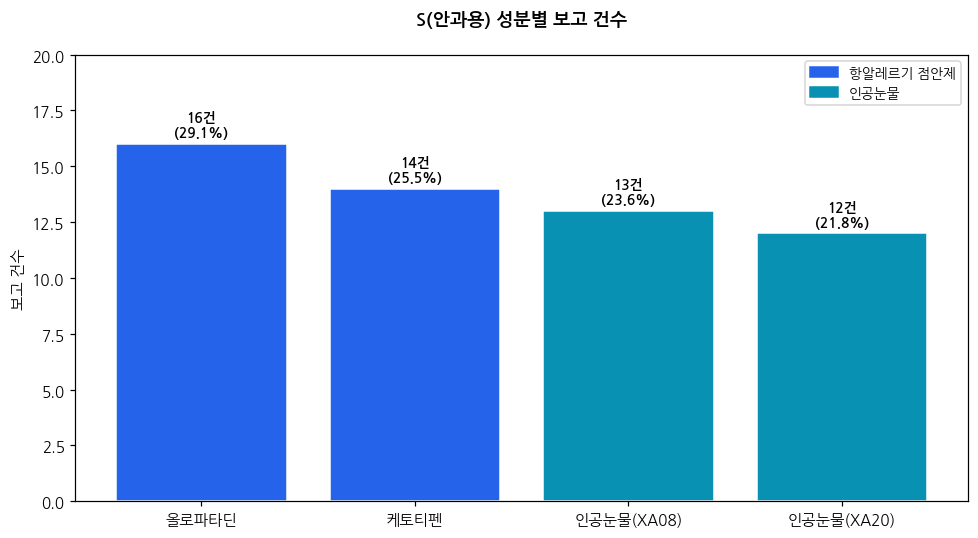




     ATC         성분  건수  비율(%)    계열
S01GX09      올로파타딘  16   29.1 항알레르기
S01GX08       케토티펜  14   25.5 항알레르기
S01XA08 인공눈물(XA08)  13   23.6  인공눈물
S01XA20 인공눈물(XA20)  12   21.8  인공눈물

[인사이트]
- S그룹은 4개 세부성분, 기능상 2계열(항알레르기 vs 인공눈물)로 깔끔히 이분.
- 올로파타딘(16) > 케토티펜(14) > 인공눈물XA08(13) > XA20(12) 순으로 고른 분포.


In [8]:
# ============================================================
# [셀 3] S그룹(안과용) 성분별 나누기
# ============================================================

s_codes = ['S01GX09','S01GX08','S01XA08','S01XA20']
s_names = [NAME_MAP[c] for c in s_codes]
s_vals  = [s_sub.get(c, 0) for c in s_codes]
# 항알레르기는 파랑, 인공눈물은 하늘색
s_colors = [C_ANTI if c in ANTI_CODES else C_SGROUP for c in s_codes]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(s_names, s_vals, color=s_colors, edgecolor='white')
for b, v in zip(bars, s_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.2, f'{v}건\n({v/N_S*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('보고 건수'); ax.set_ylim(0, max(s_vals)*1.25)
ax.set_title('S(안과용) 성분별 보고 건수', fontweight='bold', pad=20)
ax.legend(handles=[Patch(color=C_ANTI, label='항알레르기 점안제'),
                   Patch(color=C_SGROUP, label='인공눈물')], fontsize=9)
plt.tight_layout(); plt.show()

print()
print()

s_tbl = pd.DataFrame({'ATC': s_codes, '성분': s_names, '건수': s_vals})
s_tbl['비율(%)'] = (s_tbl['건수']/N_S*100).round(1)
s_tbl['계열'] = ['항알레르기' if c in ANTI_CODES else '인공눈물' for c in s_codes]
print("\n", s_tbl.to_string(index=False))

print(f"""
[인사이트]
- S그룹은 4개 세부성분, 기능상 2계열(항알레르기 vs 인공눈물)로 깔끔히 이분.
- 올로파타딘(16) > 케토티펜(14) > 인공눈물XA08(13) > XA20(12) 순으로 고른 분포.""")


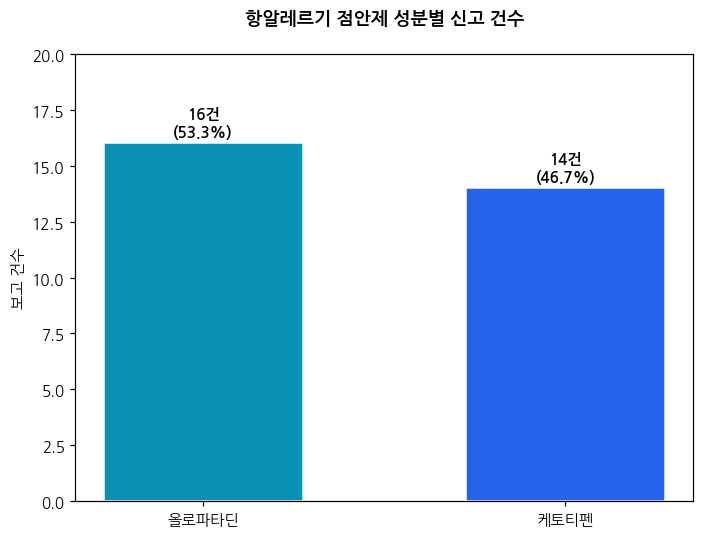


[인사이트]
- 항알레르기 점안제(30건)는 올로파타딘 16건(53.3%),
  케토티펜 14건(46.7%)로 거의 반반.
- 두 성분 모두 이중작용(H1 길항+비만세포 안정화)이라 계열로 묶어도 기전 이질성 낮음.


In [9]:
# ============================================================
# [셀 4] 항알레르기 점안제 성분별 나누기
# ============================================================

a_codes = ['S01GX09','S01GX08']
a_names = [NAME_MAP[c] for c in a_codes]
a_vals  = [int((atc == c).sum()) for c in a_codes]

fig, ax = plt.subplots(figsize=(6.5, 5))
# 올로파타딘=하늘색, 케토티펜=파랑(주 관심 성분 강조)
a_colors = [C_SGROUP, C_ANTI]
bars = ax.bar(a_names, a_vals, color=a_colors, edgecolor='white', width=0.55)
for b, v in zip(bars, a_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.2, f'{v}건\n({v/N_ANTI*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('보고 건수'); ax.set_ylim(0, max(a_vals)*1.25)
ax.set_title('항알레르기 점안제 성분별 신고 건수', fontweight='bold', pad=20)
plt.tight_layout(); plt.show()

print(f"""
[인사이트]
- 항알레르기 점안제({N_ANTI}건)는 올로파타딘 {a_vals[0]}건({a_vals[0]/N_ANTI*100:.1f}%),
  케토티펜 {a_vals[1]}건({a_vals[1]/N_ANTI*100:.1f}%)로 거의 반반.
- 두 성분 모두 이중작용(H1 길항+비만세포 안정화)이라 계열로 묶어도 기전 이질성 낮음.""")



S그룹 suspect_drug 고유 개수        : 13종
항알레르기 점안제 suspect_drug 개수 : 6종

[항알레르기 점안제 suspect_drug 내역]
suspect_drug
KETOTIFEN FUMARATE                                                 13
PATADAY                                                             9
OLOPATADINE HYDROCHLORIDE; OLOPATADINE HYDROCHLORIDE OPHTHALMIC     4
OLOPATADINE HYDROCHLORIDE OPHTHALMIC SOLUTION USP                   2
KETOTIFEN                                                           1
OLOPATADINE                                                         1
Name: count, dtype: int64


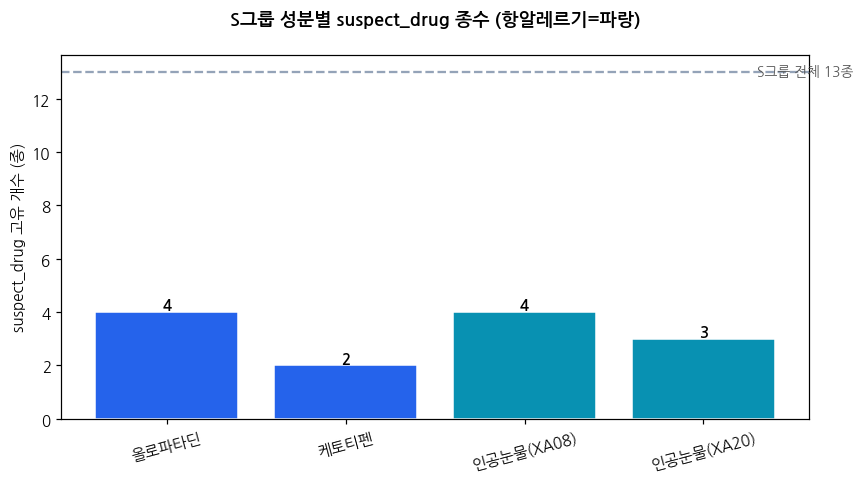


[인사이트]
- 항알레르기 점안제는 suspect_drug 6종 (케토티펜 계열 2 + 올로파타딘 계열 4).
  대부분 성분명 표기 변형이라 실질 성분은 2종 → 정합성 양호.
- 인공눈물 계열은 조성·브랜드가 다양해 상대적으로 표기 종수가 많음.


In [10]:
# ============================================================
# [셀 5] S그룹 / 항알레르기 점안제의 suspect_drug 개수
# ============================================================

n_s_drugs    = s_df['suspect_drug'].nunique()
n_anti_drugs = anti['suspect_drug'].nunique()
print(f"\nS그룹 suspect_drug 고유 개수        : {n_s_drugs}종")
print(f"항알레르기 점안제 suspect_drug 개수 : {n_anti_drugs}종")
print("\n[항알레르기 점안제 suspect_drug 내역]")
print(anti['suspect_drug'].value_counts())

fig, ax = plt.subplots(figsize=(8, 4.5))
codes = ['S01GX09','S01GX08','S01XA08','S01XA20']
nunq  = [df[atc==c]['suspect_drug'].nunique() for c in codes]
names = [NAME_MAP[c] for c in codes]
bcolors = [C_ANTI if c in ANTI_CODES else C_SGROUP for c in codes]
bars = ax.bar(names, nunq, color=bcolors, edgecolor='white')
for b, v in zip(bars, nunq):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, str(v), ha='center', fontweight='bold')
ax.axhline(n_s_drugs, color=C_BASE, linestyle='--', linewidth=1.5)
ax.text(3.3, n_s_drugs, f'S그룹 전체 {n_s_drugs}종', color='#555', va='center', fontsize=9)
ax.set_ylabel('suspect_drug 고유 개수 (종)')
ax.set_title('S그룹 성분별 suspect_drug 종수 (항알레르기=파랑)', fontweight='bold', pad=20)
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout(); plt.show()

print(f"""
[인사이트]
- 항알레르기 점안제는 suspect_drug {n_anti_drugs}종 (케토티펜 계열 2 + 올로파타딘 계열 4).
  대부분 성분명 표기 변형이라 실질 성분은 2종 → 정합성 양호.
- 인공눈물 계열은 조성·브랜드가 다양해 상대적으로 표기 종수가 많음.""")


[분포] (Unknown 제외)
    항알레르기_건수  항알레르기_%  전체_건수  전체_%
여성        22     91.7   9088  58.3
남성         2      8.3   6510  41.7


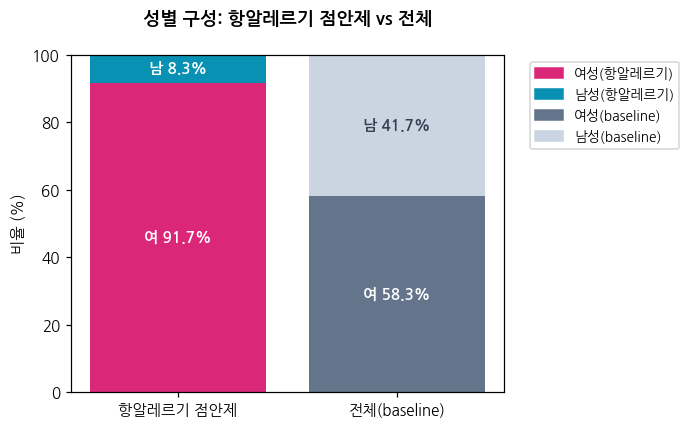


[통계검정] 성별 × 항알레르기 여부
  분할표 (2, 2), 기대빈도<5 셀 0/4
  → Chi-square
  chi2=9.696, dof=1, p-value=0.0018, Cramér's V=0.025
  유의미(p<0.05) — 소표본이므로 방향성만 참고

[인사이트]
- 항알레르기 점안제 신고자는 여성 91.7% vs 남성 8.3%로 여성 편중 매우 뚜렷
  (전체 baseline 여성 58.3% / 남성 41.7% 대비). 유효표본 24명(여22/남2).
- 알레르기성 결막염 OTC 점안제 신고의 여성 쏠림 '경향'. 소표본이라 방향성 참고.


In [11]:
# ============================================================
# [셀 6] 성별 비교
# ============================================================

def sex_dist(d):
    s = d['patient_sex'].value_counts()
    return np.array([s.get('Female', 0), s.get('Male', 0)])
a_sex, all_sex = sex_dist(anti), sex_dist(df)
a_pct, all_pct = a_sex/a_sex.sum()*100, all_sex/all_sex.sum()*100

print("\n[분포] (Unknown 제외)")
print(pd.DataFrame({'항알레르기_건수':a_sex,'항알레르기_%':a_pct.round(1),
                    '전체_건수':all_sex,'전체_%':all_pct.round(1)}, index=['여성','남성']))

# baseline 성별 색: 회색 계열 명도로 구분 (여성=진회색 / 남성=연회색)
C_BASE_F = '#64748b'   # baseline 여성 (진회색)
C_BASE_M = '#cbd5e1'   # baseline 남성 (연회색)

fig, ax = plt.subplots(figsize=(7,4))
groups = ['항알레르기 점안제','전체(baseline)']
fv = [a_pct[0], all_pct[0]]; mv = [a_pct[1], all_pct[1]]

# 항알레르기: 핑크/하늘 / baseline: 회색 명도 → 막대별로 색 지정
ax.bar(groups[0], fv[0], color=C_FEMALE)
ax.bar(groups[0], mv[0], bottom=fv[0], color=C_MALE)
ax.bar(groups[1], fv[1], color=C_BASE_F)
ax.bar(groups[1], mv[1], bottom=fv[1], color=C_BASE_M)

# 두 그룹 모두 여/남 비율 라벨 표시
for i,(f_,m_) in enumerate(zip(fv,mv)):
    ax.text(i, f_/2, f'여 {f_:.1f}%', ha='center', va='center',
            color='white', fontweight='bold')
    ax.text(i, f_+m_/2, f'남 {m_:.1f}%', ha='center', va='center',
            color='white' if i==0 else '#334155', fontweight='bold')

ax.set_ylabel('비율 (%)'); ax.set_ylim(0,100)
ax.set_title('성별 구성: 항알레르기 점안제 vs 전체', fontweight='bold', pad=20)

# 범례: 항알레르기(핑크/하늘) + baseline(회색 명도)
ax.legend(handles=[Patch(color=C_FEMALE, label='여성(항알레르기)'),
                   Patch(color=C_MALE,   label='남성(항알레르기)'),
                   Patch(color=C_BASE_F, label='여성(baseline)'),
                   Patch(color=C_BASE_M, label='남성(baseline)')],
          loc='upper right', bbox_to_anchor=(1.42,1), fontsize=9)
plt.tight_layout(); plt.show()

rest_sex = all_sex - a_sex
choose_and_run_test([[a_sex[0],a_sex[1]],[rest_sex[0],rest_sex[1]]], "성별 × 항알레르기 여부")

print(f"""
[인사이트]
- 항알레르기 점안제 신고자는 여성 {a_pct[0]:.1f}% vs 남성 {a_pct[1]:.1f}%로 여성 편중 매우 뚜렷
  (전체 baseline 여성 {all_pct[0]:.1f}% / 남성 {all_pct[1]:.1f}% 대비). 유효표본 24명(여22/남2).
- 알레르기성 결막염 OTC 점안제 신고의 여성 쏠림 '경향'. 소표본이라 방향성 참고.""")


[분포] (Unknown 제외)
            항알레르기_건수  항알레르기_%  전체_%
영아(0-2)            0      0.0   1.3
소아(3-12)           0      0.0   2.0
청소년(13-18)         1      7.1   2.4
성인(19-40)          2     14.3  12.5
중년(41-65)          2     14.3  45.3
고령(66-80)          8     57.1  28.0
초고령(81+)           1      7.1   8.6


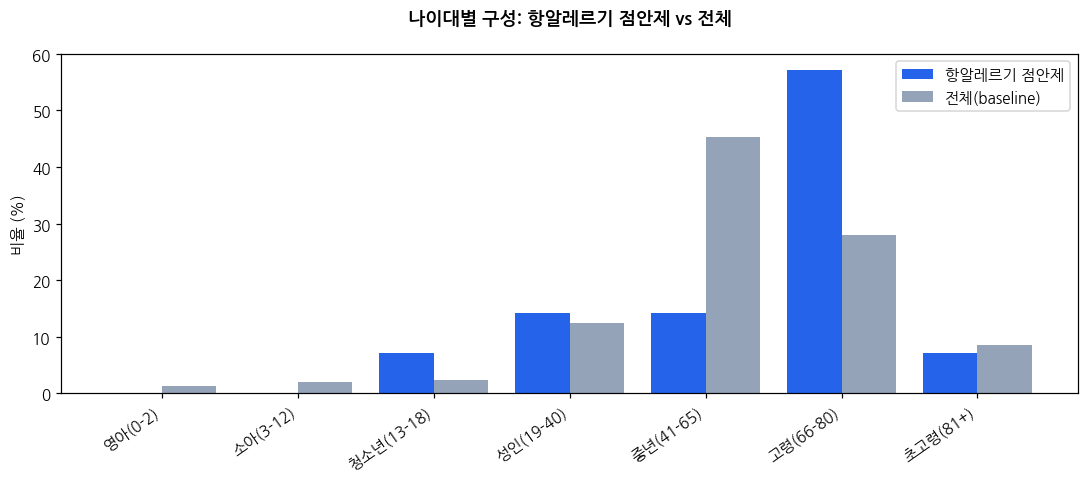


※ 셀 대부분 0~2라 '65세이하 vs 66세+' 2x2 병합 검정

[통계검정] 연령(65↓/66↑) × 항알레르기 여부
  분할표 (2, 2), 기대빈도<5 셀 0/4
  → Chi-square
  chi2=3.508, dof=1, p-value=0.0611, Cramér's V=0.016
  유의미하지 않음(p≥0.05) — 소표본이므로 방향성만 참고

[인사이트]
- 유효 연령표본 14명(Unknown 16 제외). 그중 Senior(66-80)가 8명으로 가장 큼.
- 전체 baseline 대비 고령층 신고 편중 '경향' 가능성. 표본 부족으로 단정 불가.


In [12]:
# ============================================================
# [셀 7] 나이대별 비교
# ============================================================

age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
             'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
def age_dist(d):
    s = d[d['age_group']!='Unknown']['age_group'].value_counts()
    return np.array([s.get(a,0) for a in age_order])
a_age, all_age = age_dist(anti), age_dist(df)
a_ap, all_ap = a_age/a_age.sum()*100, all_age/all_age.sum()*100

age_kr = [AGE_KR[a] for a in age_order]
print("\n[분포] (Unknown 제외)")
print(pd.DataFrame({'항알레르기_건수':a_age,'항알레르기_%':a_ap.round(1),
                    '전체_%':all_ap.round(1)}, index=age_kr))

fig, ax = plt.subplots(figsize=(10,4.5))
x = np.arange(len(age_order)); w=0.4
ax.bar(x-w/2, a_ap, w, color=C_ANTI, label='항알레르기 점안제')
ax.bar(x+w/2, all_ap, w, color=C_BASE, label='전체(baseline)')
ax.set_xticks(x); ax.set_xticklabels(age_kr, rotation=35, ha='right')
ax.set_ylabel('비율 (%)')
ax.set_title('나이대별 구성: 항알레르기 점안제 vs 전체', fontweight='bold', pad=20)
ax.legend()
plt.tight_layout(); plt.show()

# 소표본 → 65세이하 vs 66세+ 병합 2x2
def collapse_age(v): return v[:5].sum(), v[5:].sum()
ay_,ao_ = collapse_age(a_age); Ay,Ao = collapse_age(all_age)
print("\n※ 셀 대부분 0~2라 '65세이하 vs 66세+' 2x2 병합 검정")
choose_and_run_test([[ay_,ao_],[Ay-ay_,Ao-ao_]], "연령(65↓/66↑) × 항알레르기 여부")

print(f"""
[인사이트]
- 유효 연령표본 14명(Unknown 16 제외). 그중 Senior(66-80)가 8명으로 가장 큼.
- 전체 baseline 대비 고령층 신고 편중 '경향' 가능성. 표본 부족으로 단정 불가.""")



[분포] (Unknown 제외)
            항알레르기_건수  항알레르기_%  전체_%
영아(0-2)            0      0.0   1.3
소아(3-12)           0      0.0   2.0
청소년(13-18)         1      7.1   2.4
성인(19-40)          2     14.3  12.5
중년(41-65)          2     14.3  45.3
고령(66-80)          8     57.1  28.0
초고령(81+)           1      7.1   8.6


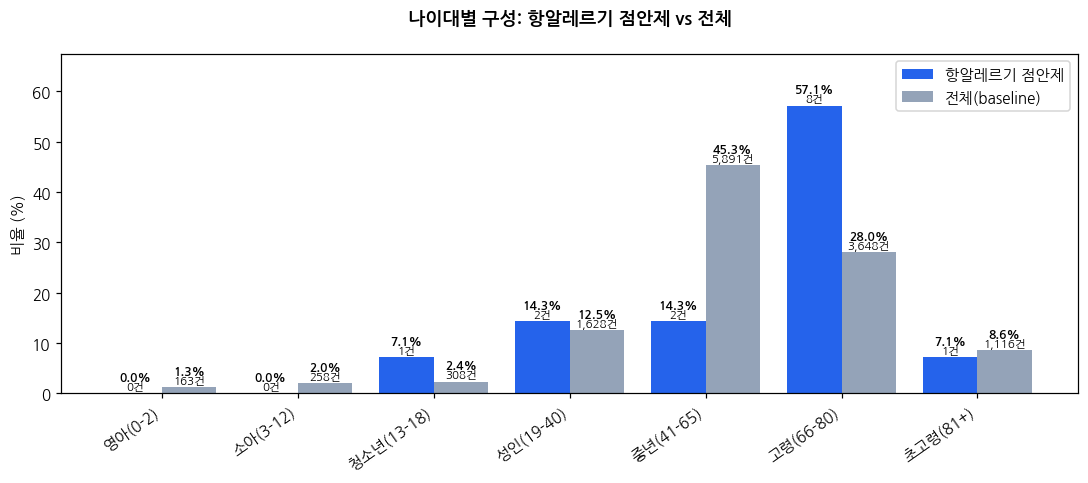


※ 셀 대부분 0~2라 '65세이하 vs 66세+' 2x2 병합 검정

[통계검정] 연령(65↓/66↑) × 항알레르기 여부
  분할표 (2, 2), 기대빈도<5 셀 0/4
  → Chi-square
  chi2=3.508, dof=1, p-value=0.0611, Cramér's V=0.016
  유의미하지 않음(p≥0.05) — 소표본이므로 방향성만 참고

[인사이트]
- 유효 연령표본 14명(Unknown 16 제외). 그중 Senior(66-80)가 8명으로 가장 큼.
- 전체 baseline 대비 고령층 신고 편중 '경향' 가능성. 표본 부족으로 단정 불가.


In [13]:
# ============================================================
# [셀 7] 나이대별 비교
# ============================================================

age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
             'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
def age_dist(d):
    s = d[d['age_group']!='Unknown']['age_group'].value_counts()
    return np.array([s.get(a,0) for a in age_order])
a_age, all_age = age_dist(anti), age_dist(df)
a_ap, all_ap = a_age/a_age.sum()*100, all_age/all_age.sum()*100

age_kr = [AGE_KR[a] for a in age_order]
print("\n[분포] (Unknown 제외)")
print(pd.DataFrame({'항알레르기_건수':a_age,'항알레르기_%':a_ap.round(1),
                    '전체_%':all_ap.round(1)}, index=age_kr))

a_total = a_age.sum(); all_total = all_age.sum()   # 유효 모집단 (Unknown 제외)

fig, ax = plt.subplots(figsize=(10,4.5))
x = np.arange(len(age_order)); w=0.4
b1 = ax.bar(x-w/2, a_ap, w, color=C_ANTI, label='항알레르기 점안제')
b2 = ax.bar(x+w/2, all_ap, w, color=C_BASE, label='전체(baseline)')
# 비율(%) + 그 아래 건수 표시
for b, p, n in zip(b1, a_ap, a_age):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2.2, f'{p:.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{n}건',
            ha='center', va='bottom', fontsize=7.5, color='black')
for b, p, n in zip(b2, all_ap, all_age):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2.2, f'{p:.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{n:,}건',
            ha='center', va='bottom', fontsize=7.5, color='black')
ax.set_xticks(x); ax.set_xticklabels(age_kr, rotation=35, ha='right')
ax.set_ylabel('비율 (%)'); ax.set_ylim(0, max(all_ap.max(), a_ap.max())*1.18)
ax.set_title('나이대별 구성: 항알레르기 점안제 vs 전체', fontweight='bold', pad=20)
ax.legend()
plt.tight_layout(); plt.show()

# 소표본 → 65세이하 vs 66세+ 병합 2x2
def collapse_age(v): return v[:5].sum(), v[5:].sum()
ay_,ao_ = collapse_age(a_age); Ay,Ao = collapse_age(all_age)
print("\n※ 셀 대부분 0~2라 '65세이하 vs 66세+' 2x2 병합 검정")
choose_and_run_test([[ay_,ao_],[Ay-ay_,Ao-ao_]], "연령(65↓/66↑) × 항알레르기 여부")

print(f"""
[인사이트]
- 유효 연령표본 14명(Unknown 16 제외). 그중 Senior(66-80)가 8명으로 가장 큼.
- 전체 baseline 대비 고령층 신고 편중 '경향' 가능성. 표본 부족으로 단정 불가.""")

9. 항알레르기 점안제 vs 전체 : 부작용 종류별 비교

항알레르기 점안제 부작용 고유 종수: 49종 → 상위 15개 표시

[항알레르기 점안제 TOP15 부작용]
      부작용  건수  항알레르기_%  전체_건수  전체_%
    약효 없음   8     26.7   1021  5.59
    눈 자극감   6     20.0     26  0.14
     눈 통증   3     10.0     20  0.11
    치료 실패   3     10.0     42  0.23
    과다 투여   2      6.7    360  1.97
    결막 충혈   2      6.7     11  0.06
    눈 가려움   2      6.7     12  0.07
   허가외 사용   2      6.7    525  2.87
   약효 불충분   1      3.3     38  0.21
   눈꺼풀 딱지   1      3.3      1  0.01
     눈 부종   1      3.3     18  0.10
점안 부위 불편감   1      3.3      5  0.03
 점안 부위 통증   1      3.3     14  0.08
   약물 오남용   1      3.3    167  0.91
   고의적 자해   1      3.3     17  0.09


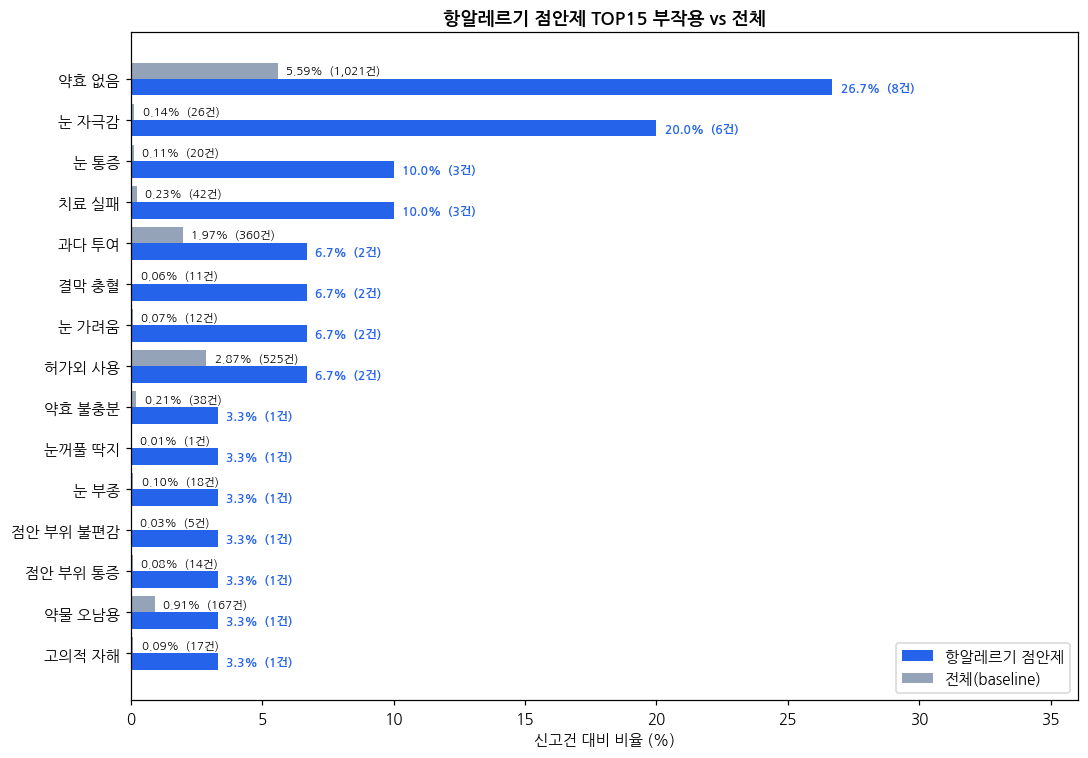


※ 대표 부작용 '약효 없음' 보유 여부 2x2 검정

[통계검정] '약효 없음' × 항알레르기 여부
  분할표 (2, 2), 기대빈도<5 셀 1/4
  → Fisher's exact (2x2 & 기대빈도 부족)
  odds ratio=6.920, p-value=0.0000
  유의미(p<0.05) — 소표본이므로 방향성만 참고

[인사이트]
- TOP 부작용은 국소·경증 위주: '약효 없음', '눈 자극감', '눈 통증' 등.
  전신 중대반응이 아닌 '약효 없음 + 점안 부위 국소반응'이 지배적인 신고 경향.
- '약효 없음'는 전체 대비 크게 높아 계열 특징 신호(방향성). 발생률 아님 유의.
- 부작용은 총 49종이나 대부분 1건짜리 롱테일 → 상위 15개로 압축 제시.


In [14]:
# ============================================================
# [셀 9] 부작용 종류별 비교
# ============================================================
print("="*60); print("9. 항알레르기 점안제 vs 전체 : 부작용 종류별 비교"); print("="*60)

def reaction_counter(d):
    c = Counter()
    for r in d['reactions'].dropna():
        for x in str(r).split(';'):
            x=x.strip()
            if x: c[x]+=1
    return c
a_rc, all_rc = reaction_counter(anti), reaction_counter(df)
n_reaction_types = len(a_rc)
TOPN = 15
print(f"\n항알레르기 점안제 부작용 고유 종수: {n_reaction_types}종 → 상위 {TOPN}개 표시")

top = a_rc.most_common(TOPN)
rt = pd.DataFrame(top, columns=['부작용(원문)','건수'])
rt['부작용'] = rt['부작용(원문)'].map(rk)
rt['항알레르기_%'] = (rt['건수']/N_ANTI*100).round(1)
# 전체 건수·비율도 함께 계산
rt['전체_건수'] = [all_rc.get(r,0) for r in rt['부작용(원문)']]
rt['전체_%'] = [round(all_rc.get(r,0)/N_ALL*100, 2) for r in rt['부작용(원문)']]
print(f"\n[항알레르기 점안제 TOP{TOPN} 부작용]")
print(rt[['부작용','건수','항알레르기_%','전체_건수','전체_%']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(rt))[::-1]
b1 = ax.barh(y-0.2, rt['항알레르기_%'], 0.4, color=C_ANTI, label='항알레르기 점안제')
b2 = ax.barh(y+0.2, rt['전체_%'], 0.4, color=C_BASE, label='전체(baseline)')
# 막대 끝에 비율 + 건수 표시 (가로 막대라 x축 방향으로 조금 띄움)
xmax = rt['항알레르기_%'].max()
off = xmax * 0.012
for b, p, n in zip(b1, rt['항알레르기_%'], rt['건수']):
    ax.text(b.get_width()+off, b.get_y()+b.get_height()/2,
            f'{p:.1f}%  ({n}건)', va='center', ha='left',
            fontsize=8, fontweight='bold', color=C_ANTI)
for b, p, n in zip(b2, rt['전체_%'], rt['전체_건수']):
    ax.text(b.get_width()+off, b.get_y()+b.get_height()/2,
            f'{p:.2f}%  ({n:,}건)', va='center', ha='left',
            fontsize=7.5, color='black')
ax.set_yticks(y); ax.set_yticklabels(rt['부작용'])
ax.set_xlabel('신고건 대비 비율 (%)')
ax.set_xlim(0, xmax*1.35)   # 라벨 공간 확보
ax.set_title(f'항알레르기 점안제 TOP{TOPN} 부작용 vs 전체', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

top1 = top[0][0]                # 원문 (문자열 매칭용)
top1_kr = rk(top1)              # 한글 표기
k_has = sum(top1 in str(r) for r in anti['reactions'].dropna())
a_has = sum(top1 in str(r) for r in df['reactions'].dropna())
print(f"\n※ 대표 부작용 '{top1_kr}' 보유 여부 2x2 검정")
choose_and_run_test([[k_has, N_ANTI-k_has],
                     [a_has-k_has, (N_ALL-N_ANTI)-(a_has-k_has)]],
                    f"'{top1_kr}' × 항알레르기 여부")

print(f"""
[인사이트]
- TOP 부작용은 국소·경증 위주: '{rk(top[0][0])}', '{rk(top[1][0])}', '{rk(top[2][0])}' 등.
  전신 중대반응이 아닌 '약효 없음 + 점안 부위 국소반응'이 지배적인 신고 경향.
- '{top1_kr}'는 전체 대비 크게 높아 계열 특징 신호(방향성). 발생률 아님 유의.
- 부작용은 총 {n_reaction_types}종이나 대부분 1건짜리 롱테일 → 상위 {TOPN}개로 압축 제시.""")

10-1. 항알레르기 점안제 serious 5건의 종류별 구성

serious=Yes 총 5건 구성:
  사망: 0건
  입원: 3건
  생명위협: 0건
  장애: 0건
  종류 미상: 2건
※ serious_flags가 복수면 한 건이 여러 종류에 중복될 수 있음


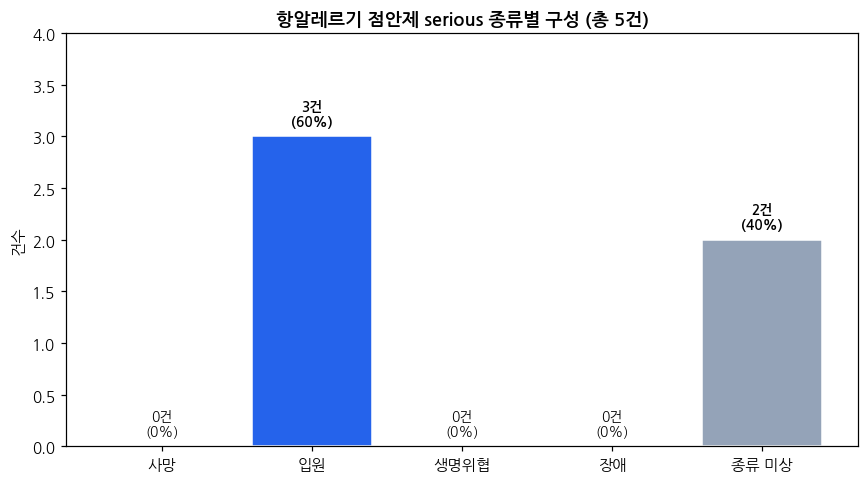


[인사이트]
- serious 5건 중 실제 종류가 기재된 건 '입원' 3건뿐 —
  사망·생명위협·장애는 0건. 중대반응이라도 '입원 수준'이 최대.
- 나머지 2건은 serious=Yes지만 세부 종류 미기재('종류 미상').
  → 셀 10의 serious 5건과 종류별 그래프(입원 3건)의 차이는 이 미상 2건 때문.
- OTC 안과 점안제의 저중증도 프로파일을 재확인. 단 n=5 소표본이라 경향 참고.


In [15]:
# ============================================================
# [셀 10-1] serious 5건의 종류별 구성 (항알레르기 점안제)
# ============================================================
print("="*60); print("10-1. 항알레르기 점안제 serious 5건의 종류별 구성"); print("="*60)

sy = anti[anti['serious'] == 'Yes']
N_SY = len(sy)   # 5건

# 4개 플래그 + '종류 미상'(4개 모두 False)
flag_cols = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']
flag_kr   = ['사망', '입원', '생명위협', '장애']
type_cnt  = [int(sy[f].sum()) for f in flag_cols]

# 종류 미상 = serious=Yes지만 세부 플래그가 하나도 없는 건
none_mask = (sy[flag_cols].sum(axis=1) == 0)
n_none = int(none_mask.sum())
type_cnt.append(n_none)
flag_kr.append('종류 미상')

print(f"\nserious=Yes 총 {N_SY}건 구성:")
for k, c in zip(flag_kr, type_cnt):
    print(f"  {k}: {c}건")
print("※ serious_flags가 복수면 한 건이 여러 종류에 중복될 수 있음")

# 색상: 입원=파랑(주 종류), 미상=회색, 나머지=하늘색
bar_colors = []
for k in flag_kr:
    if k == '입원':        bar_colors.append(C_ANTI)
    elif k == '종류 미상':  bar_colors.append(C_BASE)
    else:                  bar_colors.append(C_SGROUP)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(flag_kr, type_cnt, color=bar_colors, edgecolor='white')
for b, c in zip(bars, type_cnt):
    ax.text(b.get_x()+b.get_width()/2, c + 0.08,
            f'{c}건\n({c/N_SY*100:.0f}%)', ha='center', va='bottom',
            fontsize=9, fontweight='bold' if c > 0 else 'normal',
            color='black')
ax.set_ylabel('건수'); ax.set_ylim(0, max(type_cnt) + 1)
ax.set_title(f'항알레르기 점안제 serious 종류별 구성 (총 {N_SY}건)', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"""
[인사이트]
- serious {N_SY}건 중 실제 종류가 기재된 건 '입원' {type_cnt[1]}건뿐 —
  사망·생명위협·장애는 0건. 중대반응이라도 '입원 수준'이 최대.
- 나머지 {n_none}건은 serious=Yes지만 세부 종류 미기재('종류 미상').
  → 셀 10의 serious 5건과 종류별 그래프(입원 3건)의 차이는 이 미상 {n_none}건 때문.
- OTC 안과 점안제의 저중증도 프로파일을 재확인. 단 n={N_SY} 소표본이라 경향 참고.""")

13. serious 종류별 회복률

[전체 baseline serious 종류별 회복률]
      회복률(%)     n
사망       8.9  2637
입원      32.8  6281
생명위협    46.8  1012
장애      14.5   574

항알레르기 입원 표본: 3건, 회복률 0.0%


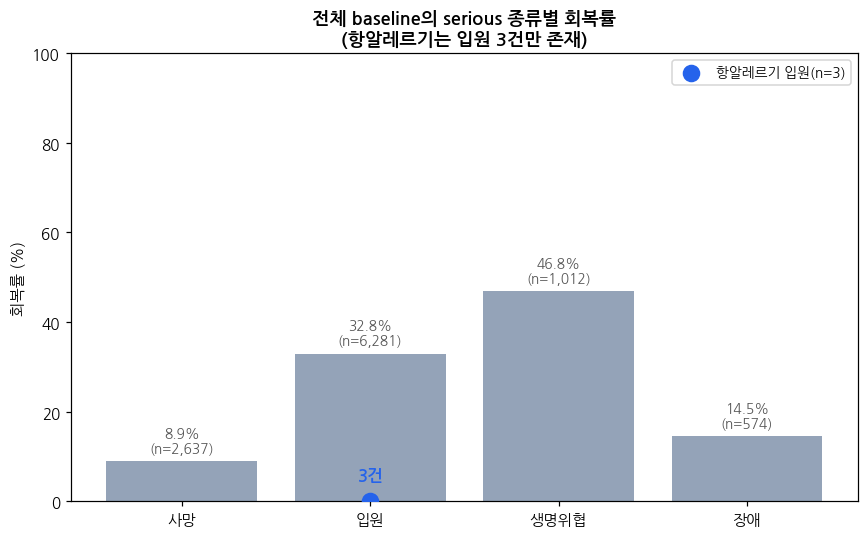


[인사이트]
- 전체 baseline 회복률은 생명위협(46.8%)>입원(32.8%)>장애(14.5%)>사망(8.9%) 순.
- 항알레르기 점안제는 serious 중 '입원' 3건만 존재(사망·생명위협·장애 0건).
  그 입원 3건의 회복률 0.0%는 전체 입원(32.8%)보다 낮게 보이나,
  표본 3건뿐이라 '결과 미상' 포함 가능성이 커 의미 부여 어려움.
- patient_recovered=False에 '미회복'과 '미상'이 섞여있는 한계 재확인.


In [16]:
# ============================================================
# [셀 13] serious 종류별 회복률 (전체 baseline)
# ============================================================
print("="*60); print("13. serious 종류별 회복률"); print("="*60)

def recover_rate(d):
    return (d['patient_recovered'] == True).mean() * 100 if len(d) > 0 else np.nan

# 전체 baseline의 serious '종류별' 회복률
flag_cols = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']
flag_kr   = ['사망', '입원', '생명위협', '장애']
A_type_rr = [recover_rate(df[df[f]==1]) for f in flag_cols]
A_type_n  = [int((df[f]==1).sum()) for f in flag_cols]

print("\n[전체 baseline serious 종류별 회복률]")
print(pd.DataFrame({'회복률(%)': np.round(A_type_rr,1), 'n': A_type_n}, index=flag_kr))

# 항알레르기 입원 표본
a_hosp = anti[anti['is_hospitalized']==1]
a_hosp_rr = recover_rate(a_hosp)
a_hosp_n  = len(a_hosp)
print(f"\n항알레르기 입원 표본: {a_hosp_n}건, 회복률 {a_hosp_rr:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(flag_kr, A_type_rr, color=C_BASE)
for b, r, n in zip(bars, A_type_rr, A_type_n):
    ax.text(b.get_x()+b.get_width()/2, r+1.5, f'{r:.1f}%\n(n={n:,})',
            ha='center', va='bottom', fontsize=9, color='#555')

# 항알레르기 입원 3건 회복률 점 + '3건' 라벨
ax.scatter([1], [a_hosp_rr], color=C_ANTI, s=110, zorder=5,
           label=f'항알레르기 입원(n={a_hosp_n})')
ax.text(1, a_hosp_rr + 4, f'{a_hosp_n}건', ha='center', va='bottom',
        color=C_ANTI, fontweight='bold', fontsize=11)

ax.set_ylabel('회복률 (%)'); ax.set_ylim(0, 100)
ax.set_title('전체 baseline의 serious 종류별 회복률\n(항알레르기는 입원 3건만 존재)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"""
[인사이트]
- 전체 baseline 회복률은 생명위협({A_type_rr[2]:.1f}%)>입원({A_type_rr[1]:.1f}%)>장애({A_type_rr[3]:.1f}%)>사망({A_type_rr[0]:.1f}%) 순.
- 항알레르기 점안제는 serious 중 '입원' {a_hosp_n}건만 존재(사망·생명위협·장애 0건).
  그 입원 3건의 회복률 {a_hosp_rr:.1f}%는 전체 입원({A_type_rr[1]:.1f}%)보다 낮게 보이나,
  표본 3건뿐이라 '결과 미상' 포함 가능성이 커 의미 부여 어려움.
- patient_recovered=False에 '미회복'과 '미상'이 섞여있는 한계 재확인.""")